⭐ Project By -Anshi Sharma

# 📧 Spam Email Detection


## ⭐ 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## ⭐ 2. Data Collection & Pre-Processing

In [2]:
raw_mail_data = pd.read_csv("mail_data.csv")

# Replace null values with empty string
mail_data = raw_mail_data.where(pd.notnull(raw_mail_data), '')

# Label encoding: spam=0, ham=1
mail_data.loc[mail_data['Category'] == 'spam', 'Category'] = 0
mail_data.loc[mail_data['Category'] == 'ham',  'Category'] = 1
mail_data['Category'] = mail_data['Category'].astype(int)

print('Dataset shape:', mail_data.shape)
mail_data.head()

Dataset shape: (5572, 2)


,Category,Message
0,1,"Go until jurong point, crazy.. Available only ..."
1,1,Ok lar... Joking wif u oni...
2,0,Free entry in 2 a wkly comp to win FA Cup fina...
3,1,U dun say so early hor... U c already then say...
4,1,"Nah I don't think he goes to usf, he lives aro..."


## ⭐ 3. Exploratory Data Analysis (EDA)

Before training, we explore the data to understand its structure, class balance, and word patterns.

### 3a. Class Distribution

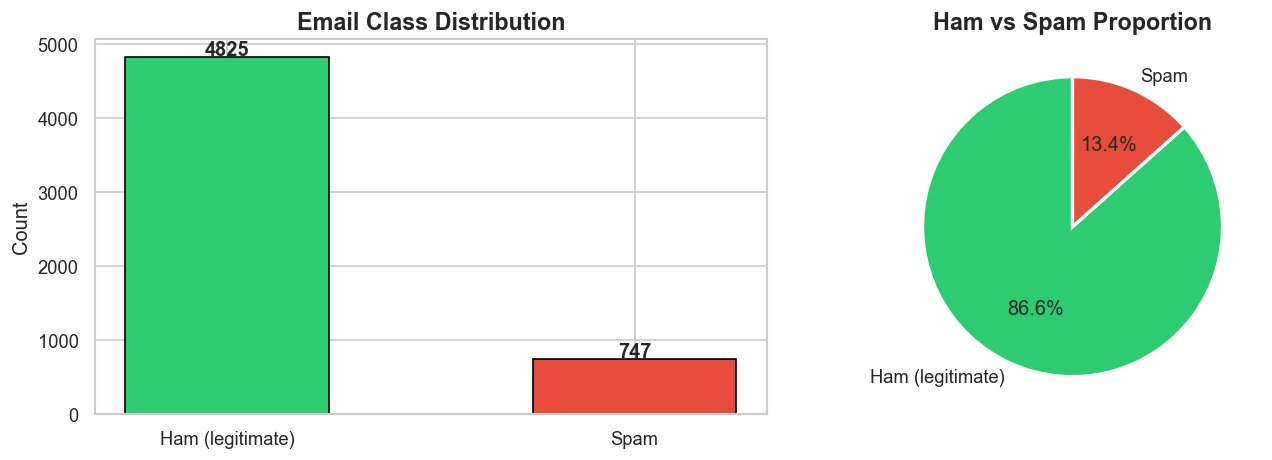

Ham emails : 4825  (86.6%)
Spam emails: 747  (13.4%)


In [3]:
label_counts = mail_data['Category'].value_counts()
labels = ['Ham (legitimate)', 'Spam']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(labels, label_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Email Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Ham vs Spam Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Ham emails : {label_counts[1]}  ({label_counts[1]/len(mail_data)*100:.1f}%)')
print(f'Spam emails: {label_counts[0]}  ({label_counts[0]/len(mail_data)*100:.1f}%)')

### 3b. Message Length Analysis

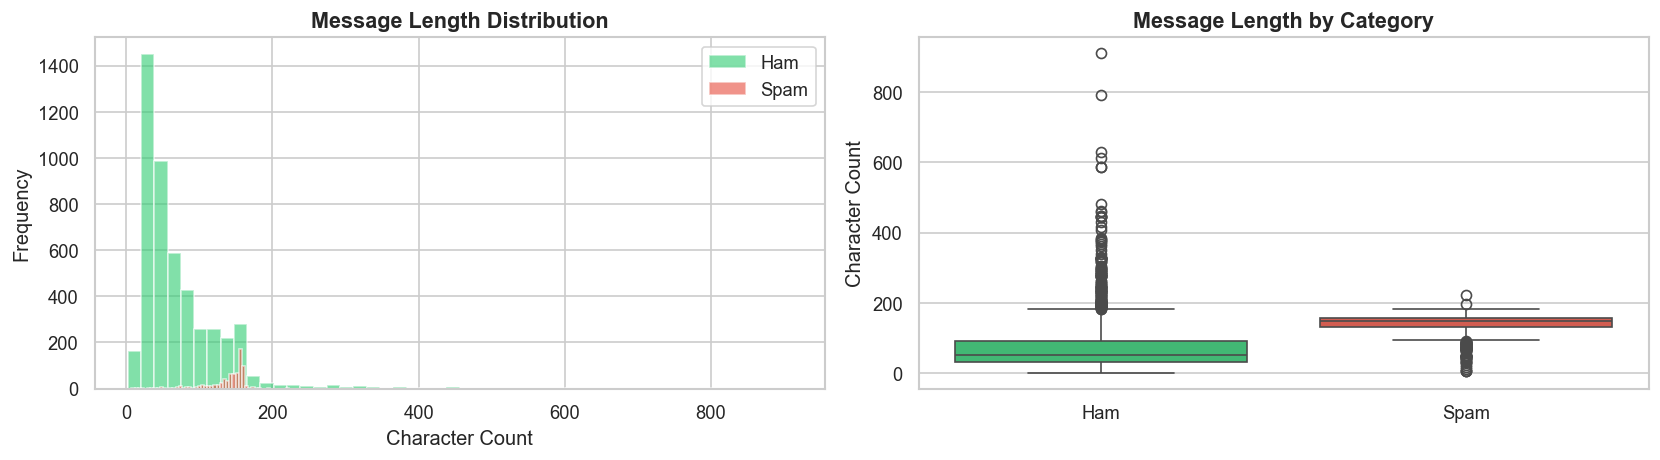

Average message length:
Label
Ham      71.4
Spam    138.0


In [4]:
mail_data['msg_length'] = mail_data['Message'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution by class
for label, color, name in [(1, '#2ecc71', 'Ham'), (0, '#e74c3c', 'Spam')]:
    subset = mail_data[mail_data['Category'] == label]['msg_length']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=name, edgecolor='white')
axes[0].set_title('Message Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
mail_data['Label'] = mail_data['Category'].map({1: 'Ham', 0: 'Spam'})
sns.boxplot(data=mail_data, x='Label', y='msg_length',
            palette={'Ham': '#2ecc71', 'Spam': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Message Length by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Character Count')

plt.tight_layout()
plt.show()

print('Average message length:')
print(mail_data.groupby('Label')['msg_length'].mean().round(1).to_string())

### 3c. Word Clouds — Most Common Words in Spam vs Ham

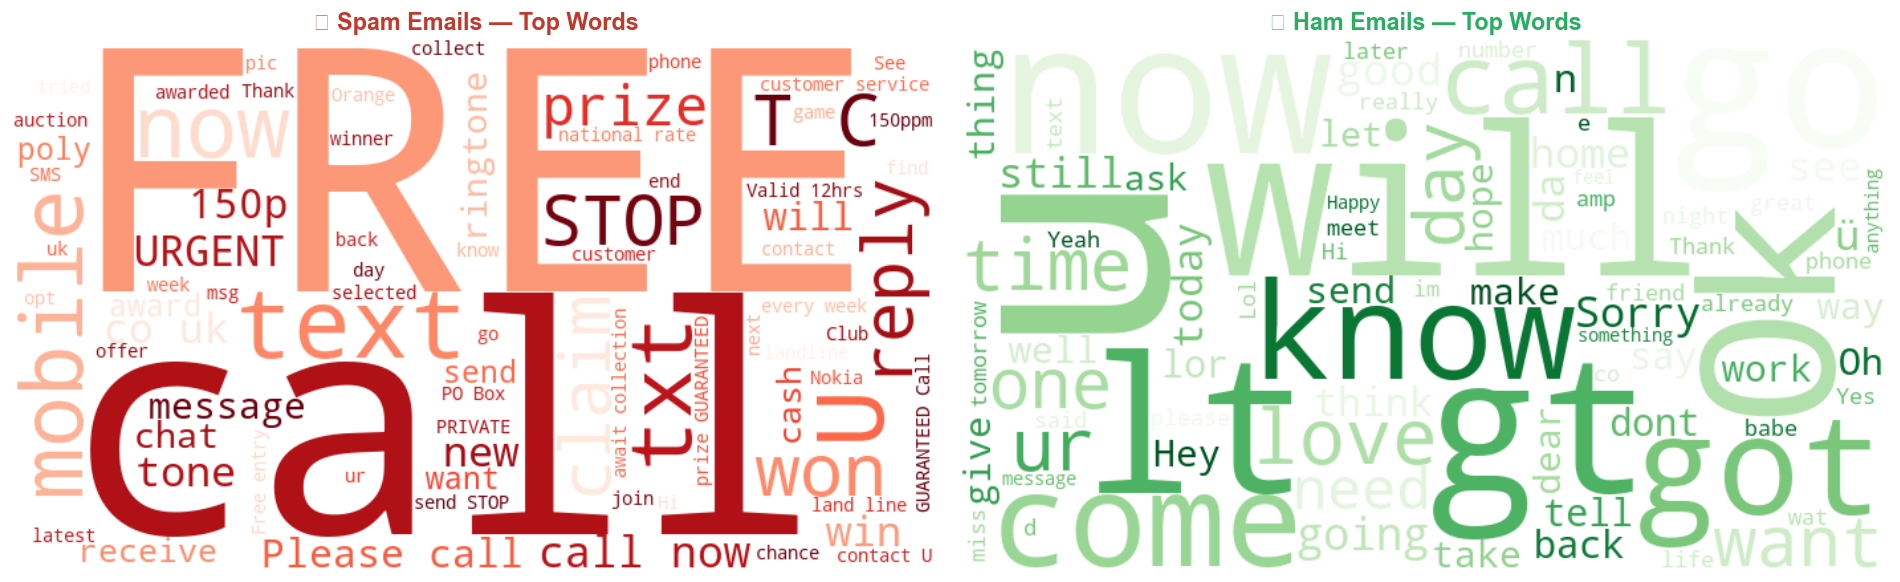

In [5]:
spam_text = ' '.join(mail_data[mail_data['Category'] == 0]['Message'])
ham_text  = ' '.join(mail_data[mail_data['Category'] == 1]['Message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_spam = WordCloud(width=700, height=400, background_color='white',
                    colormap='Reds', max_words=80).generate(spam_text)
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('🚫 Spam Emails — Top Words', fontsize=14, fontweight='bold', color='#c0392b')

wc_ham = WordCloud(width=700, height=400, background_color='white',
                   colormap='Greens', max_words=80).generate(ham_text)
axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('✅ Ham Emails — Top Words', fontsize=14, fontweight='bold', color='#27ae60')

plt.tight_layout()
plt.show()

### 3d. Top 15 Most Frequent Words

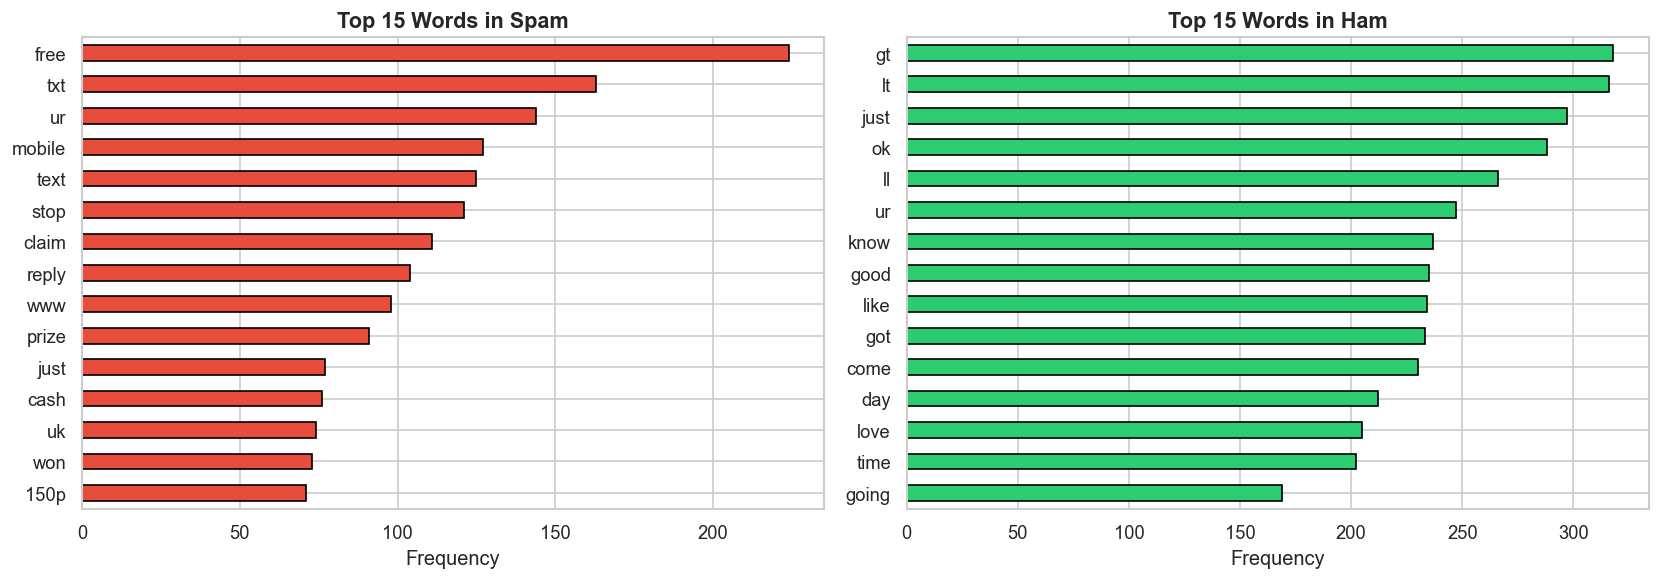

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

def top_words(text_series, n=15):
    cv = CountVectorizer(stop_words='english', max_features=n)
    cv.fit_transform(text_series)
    freq = cv.transform(text_series).toarray().sum(axis=0)
    return pd.Series(freq, index=cv.get_feature_names_out()).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_spam = top_words(mail_data[mail_data['Category'] == 0]['Message'])
top_spam.plot(kind='barh', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Top 15 Words in Spam', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

top_ham = top_words(mail_data[mail_data['Category'] == 1]['Message'])
top_ham.plot(kind='barh', ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title('Top 15 Words in Ham', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## ⭐ 4. Feature Extraction & Train/Test Split

In [7]:
X = mail_data['Message']
Y = mail_data['Category']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=3
)

# TF-IDF vectorization
tfidf = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)
X_train_features = tfidf.fit_transform(X_train)
X_test_features  = tfidf.transform(X_test)

Y_train = Y_train.astype('int')
Y_test  = Y_test.astype('int')

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Vocabulary size  : {len(tfidf.vocabulary_)}')

Training samples : 4457
Test samples     : 1115
Vocabulary size  : 7431


## ⭐ 5. Training & Comparing Multiple Models

We train three different classifiers and compare their performance side-by-side.

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes'        : MultinomialNB(),
    'SVM (Linear)'       : LinearSVC(max_iter=1000),
}

results = {}
trained = {}

for name, clf in models.items():
    clf.fit(X_train_features, Y_train)
    y_pred_train = clf.predict(X_train_features)
    y_pred_test  = clf.predict(X_test_features)
    results[name] = {
        'Train Accuracy': accuracy_score(Y_train, y_pred_train),
        'Test Accuracy' : accuracy_score(Y_test,  y_pred_test),
        'y_pred'        : y_pred_test
    }
    trained[name] = clf
    print(f'{name:25s}  Train: {results[name]["Train Accuracy"]:.4f}  Test: {results[name]["Test Accuracy"]:.4f}')

Logistic Regression        Train: 0.9677  Test: 0.9668
Naive Bayes                Train: 0.9807  Test: 0.9731
SVM (Linear)               Train: 0.9993  Test: 0.9821


## ⭐ 6. Detailed Evaluation — Precision, Recall, F1 & Confusion Matrix

> **Why accuracy alone isn't enough:** If 87% of emails are ham, a model that labels *everything* as ham gets 87% accuracy — but catches zero spam. Precision, Recall, and F1-score reveal the true picture.

### 6a. Classification Reports

In [9]:
for name, res in results.items():
    print(f'{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(classification_report(Y_test, res['y_pred'],
                                target_names=['Spam (0)', 'Ham (1)']))
    print()

  Logistic Regression
              precision    recall  f1-score   support

    Spam (0)       1.00      0.76      0.86       155
     Ham (1)       0.96      1.00      0.98       960

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115


  Naive Bayes
              precision    recall  f1-score   support

    Spam (0)       1.00      0.81      0.89       155
     Ham (1)       0.97      1.00      0.98       960

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115


  SVM (Linear)
              precision    recall  f1-score   support

    Spam (0)       0.99      0.88      0.93       155
     Ham (1)       0.98      1.00      0.99       960

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.

### 6b. Confusion Matrices

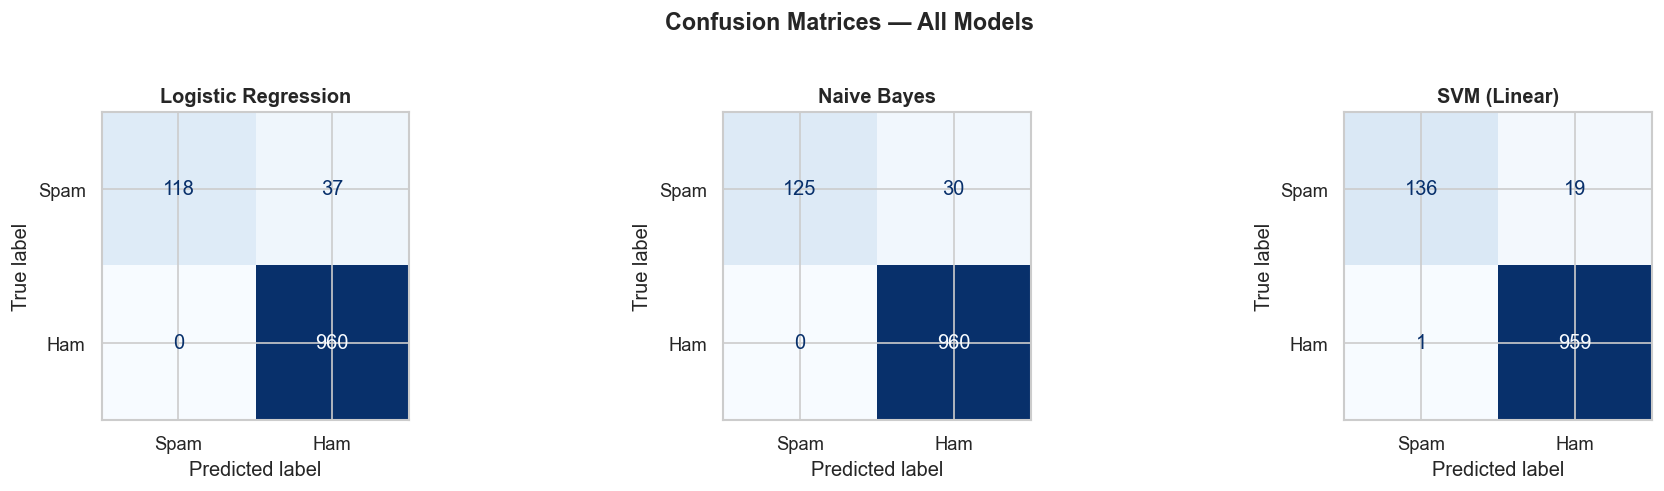

Rows = Actual class  |  Columns = Predicted class


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(Y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Spam', 'Ham'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Rows = Actual class  |  Columns = Predicted class')

### 6c. Model Performance Comparison Chart

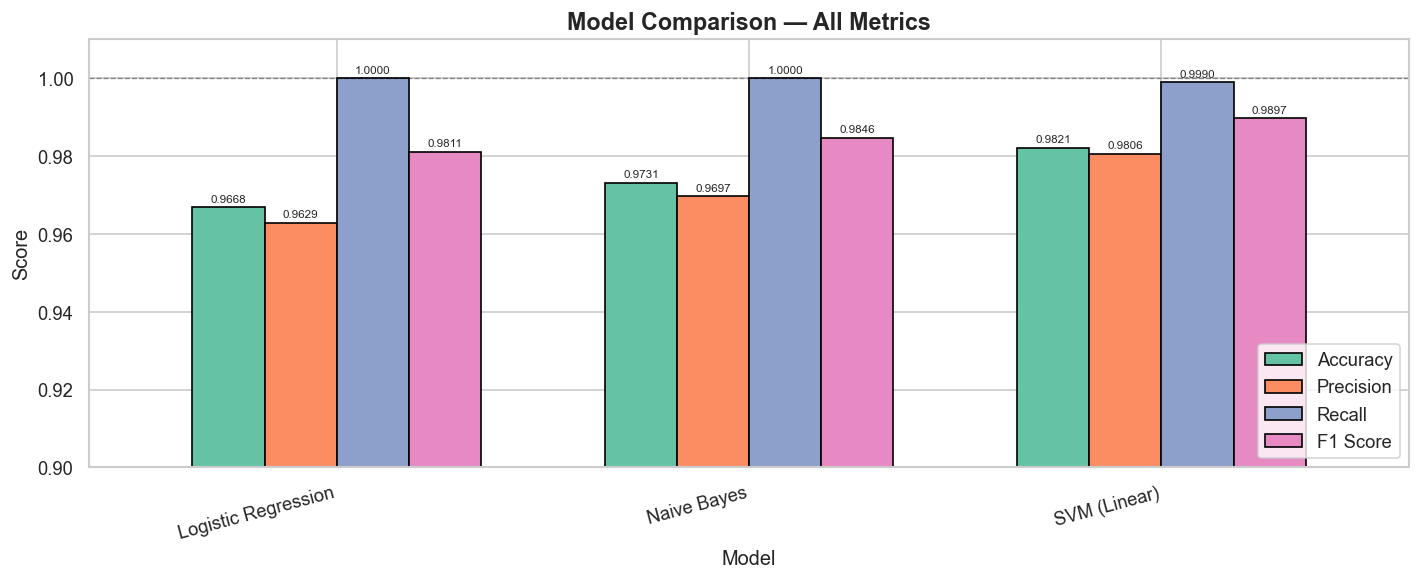


Full metrics table:
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.9668     0.9629   1.000    0.9811
Naive Bayes            0.9731     0.9697   1.000    0.9846
SVM (Linear)           0.9821     0.9806   0.999    0.9897


In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score

metrics_data = []
for name, res in results.items():
    y_pred = res['y_pred']
    metrics_data.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(Y_test, y_pred),
        'Precision': precision_score(Y_test, y_pred),
        'Recall'   : recall_score(Y_test, y_pred),
        'F1 Score' : f1_score(Y_test, y_pred),
    })

metrics_df = pd.DataFrame(metrics_data).set_index('Model')

ax = metrics_df.plot(kind='bar', figsize=(12, 5), edgecolor='black', width=0.7)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0.9, 1.01)
ax.set_xticklabels(metrics_df.index, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=7, padding=2)

plt.tight_layout()
plt.show()
print('\nFull metrics table:')
print(metrics_df.round(4).to_string())

## ⭐ 7. Best Model Selection

In [12]:
best_name = metrics_df['F1 Score'].idxmax()
best_model = trained[best_name]

print(f'🏆 Best Model by F1 Score: {best_name}')
print(f"   Accuracy : {metrics_df.loc[best_name, 'Accuracy']:.4f}")
print(f"   Precision: {metrics_df.loc[best_name, 'Precision']:.4f}")
print(f"   Recall   : {metrics_df.loc[best_name, 'Recall']:.4f}")
print(f"   F1 Score : {metrics_df.loc[best_name, 'F1 Score']:.4f}")

🏆 Best Model by F1 Score: SVM (Linear)
   Accuracy : 0.9821
   Precision: 0.9806
   Recall   : 0.9990
   F1 Score : 0.9897


## ⭐ 8. Predictive System

In [13]:
def predict_email(email_text, model=best_model, vectorizer=tfidf):
    """Predict whether an email is spam or ham."""
    features = vectorizer.transform([email_text])
    pred = model.predict(features)[0]
    label = '✅ Ham (Legitimate)' if pred == 1 else '🚫 Spam'
    print(f'Email: "{email_text[:80]}..."' if len(email_text) > 80 else f'Email: "{email_text}"')
    print(f'Prediction: {label}')
    print(f'Model used: {best_name}')
    return pred

# ── Test examples ──
print('='*60)
predict_email("Congratulations! You've won a FREE iPhone. Click now to claim your prize!!!")
print('='*60)
predict_email("Hey, are we still meeting for lunch tomorrow at 1pm?")
print('='*60)
predict_email("URGENT: Your bank account has been compromised. Call us immediately to verify.")
print('='*60)

Email: "Congratulations! You've won a FREE iPhone. Click now to claim your prize!!!"
Prediction: 🚫 Spam
Model used: SVM (Linear)
Email: "Hey, are we still meeting for lunch tomorrow at 1pm?"
Prediction: ✅ Ham (Legitimate)
Model used: SVM (Linear)
Email: "URGENT: Your bank account has been compromised. Call us immediately to verify."
Prediction: 🚫 Spam
Model used: SVM (Linear)
